In [ ]:
# Importing data directly from kaggle

import kagglehub

# Download latest version
path = kagglehub.dataset_download("umehabiba02468/cat-vs-dog-claasification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-vs-dog-claasification' dataset.
Path to dataset files: /kaggle/input/cat-vs-dog-claasification


In [ ]:
# 2nd data

import kagglehub

# Download latest version
path = kagglehub.dataset_download("link45/cat-v-s-dog")

print("Path to dataset files:", path)

100%|██████████| 239M/239M [00:02<00:00, 96.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/link45/cat-v-s-dog/versions/1


In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 772.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 22.6 MB/s eta 0:00:00


In [ ]:
# Importing req libraries

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten

In [ ]:
# Data loading using generators

train_ds = keras.utils.image_dataset_from_directory(
    directory = '/root/.cache/kagglehub/datasets/link45/cat-v-s-dog/versions/1/cat_vs_dog/train',
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
)


validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/kaggle/input/cat-vs-dog-claasification/test_set/test_set',
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
)

Found 10000 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [ ]:
# Normalizing to make all pixel values between 0-1

def process(image, label):
  image = tf.cast(image/255., tf.float32)
  return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
# Create CNN Model

# Model object
model = Sequential()

# Add Input Layer (recommended by Keras warning)
model.add(keras.Input(shape=(256, 256, 3)))

# 1st layer

# Convolution
model.add(Conv2D(32, kernel_size = (3,3), padding = 'valid', activation = 'relu'))

# Pooling
model.add(MaxPool2D(pool_size = (2,2), strides = 2, padding = 'valid'))


# 2nd layer

# Convolution
model.add(Conv2D(64, kernel_size = (3,3), padding = 'valid', activation = 'relu'))

# Pooling
model.add(MaxPool2D(pool_size = (2,2), strides = 2, padding = 'valid'))


# 3rd layer

# Convolution
model.add(Conv2D(128, kernel_size = (3,3), padding = 'valid', activation = 'relu'))

# Pooling
model.add(MaxPool2D(pool_size = (2,2), strides = 2, padding = 'valid'))


# 4th - Flatten layer
model.add(Flatten())


# 5th - Fully connected layer
model.add(Dense(units = 128, activation = 'relu'))
model.add(Dense(units = 64, activation = 'relu'))
model.add(Dense(units = 1, activation = 'sigmoid'))

In [ ]:
# Model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model compiling

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
# Model fitting

history = model.fit(train_ds, epochs = 10, validation_data = validation_ds)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 111ms/step - accuracy: 0.5253 - loss: 0.7334 - val_accuracy: 0.5635 - val_loss: 0.8727
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.6689 - loss: 0.6095 - val_accuracy: 0.7652 - val_loss: 0.4943
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - accuracy: 0.7577 - loss: 0.4933 - val_accuracy: 0.8196 - val_loss: 0.3827
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.8256 - loss: 0.3838 - val_accuracy: 0.8695 - val_loss: 0.2987
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 80ms/step - accuracy: 0.8908 - loss: 0.2508 - val_accuracy: 0.8903 - val_loss: 0.2827
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 78ms/step - accuracy: 0.9404 - loss: 0.1503 - val_accuracy: 0.9278 - val_loss: 0.1833
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.9624 - loss: 0.1011 - val_accuracy: 0.9372 - val_loss: 0.1514
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.9790 - loss: 0.0602 -

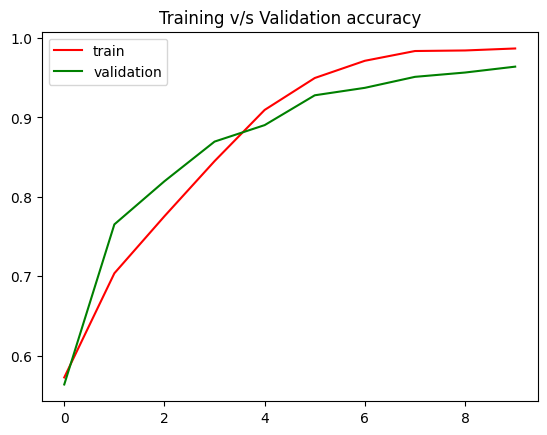

In [ ]:
# Plotting training v/s validation accuracy

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color = 'red', label = 'train')
plt.plot(history.history['val_accuracy'], color = 'green', label = 'validation')
plt.title('Training v/s Validation accuracy')
plt.legend()
plt.show()

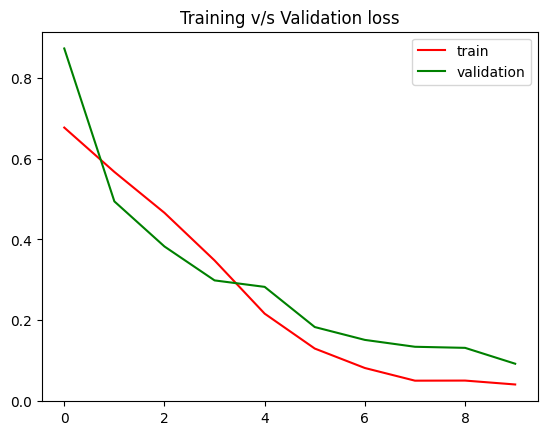

In [ ]:
# Plotting training v/s validation accuracy

import matplotlib.pyplot as plt

plt.plot(history.history['loss'], color = 'red', label = 'train')
plt.plot(history.history['val_loss'], color = 'green', label = 'validation')
plt.title('Training v/s Validation loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 881ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━

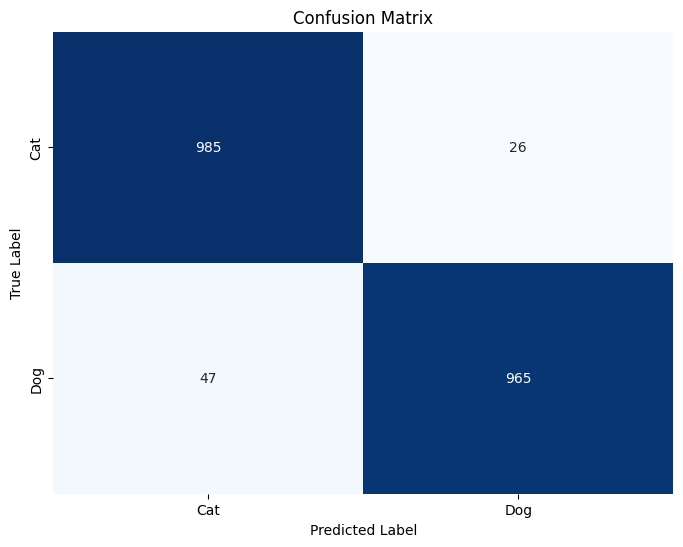

In [ ]:
# Confusion marix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get true labels and predictions from the validation dataset
y_true = []
y_pred_raw = []

for images, labels in validation_ds:
    y_true.extend(labels.numpy())
    y_pred_raw.extend(model.predict(images).flatten())

y_true = np.array(y_true)
y_pred_raw = np.array(y_pred_raw)

# Convert raw predictions (probabilities) to binary predictions (0 or 1)
y_pred = (y_pred_raw > 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Prediction

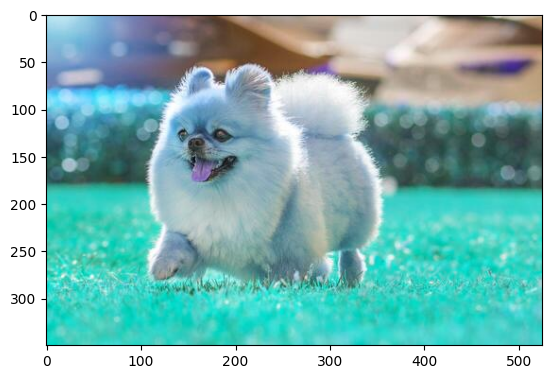

In [ ]:
import cv2
test_img = cv2.imread('/dog.jpg')
plt.imshow(test_img)
plt.show()

In [ ]:
# Shape of testimage

test_img.shape

(350, 525, 3)

In [ ]:
# Reszing image to pass into the model

test_img_resize = cv2.resize(test_img, (256, 256))
test_img_resize.shape

(256, 256, 3)

In [ ]:
# Reshaping input to pass one input in the batch

test_input = test_img_resize.reshape((1,256,256,3))

In [ ]:
# Predicting

prediction = model.predict(test_input)

if prediction == 1:
  print('The image is of a dog')
else:
  print('The image is of a cat')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
The image is of a dog
